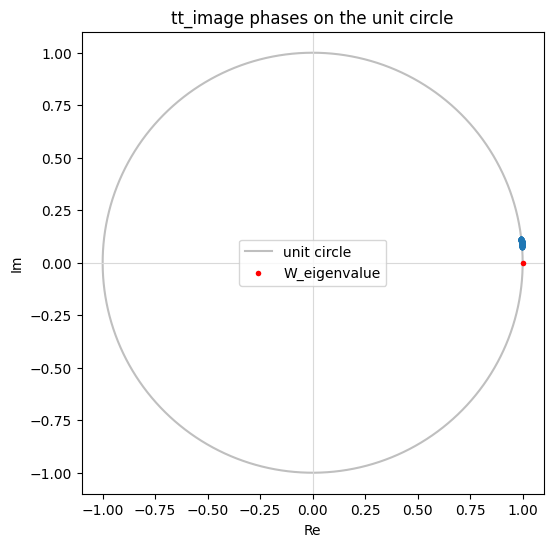

In [2]:
from eigenstate_solving import BZ_proj
import numpy as np
from band_gap import _sample_for_k
from model import square_lattice
from smatrix import create_self_energy_interpolator_numba,t_reg
import matplotlib.pyplot as plt
from eigenstate_solving import BZ_proj



sigma_data = np.load("../../data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = sigma_func_period_numba(
    0, 0).real


r_para = np.array([-74, 30])
Q_para = np.array([0,0])
E = 2*(square_lattice.omega_e + collective_lamb_shift)

# labels for W state
p_para = np.array([0,0])
E1 = (E-2)/2

W_eigenvalue = t_reg(p_para, E1, square_lattice, sigma_func_period_numba) * t_reg(BZ_proj(Q_para - p_para,square_lattice), E - E1, square_lattice, sigma_func_period_numba)

tt_image = _sample_for_k(r_para,
    Q_para,
    E,
    1e-10,
    100,
    sigma_func_period_numba,
    square_lattice)




values = np.asarray(tt_image, dtype=complex)
finite_nonzero = np.isfinite(values.real) & np.isfinite(values.imag) & (np.abs(values) > 0)
unit_values = values[finite_nonzero]

theta = np.linspace(0, 2 * np.pi, 600)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta), np.sin(theta), color="0.75", lw=1.5, label="unit circle")
ax.scatter(
    unit_values.real,
    unit_values.imag,
    color="tab:blue",
    s=16,
    edgecolor="black",
    linewidth=0.0,
    zorder=3,
)

W_unit = W_eigenvalue
ax.scatter(
    W_unit.real,
    W_unit.imag,
    color="red",
    s=16,
    edgecolor="black",
    linewidth=0.0,
    zorder=4,
    label="W_eigenvalue",
)

ax.axhline(0, color="0.85", lw=0.8)
ax.axvline(0, color="0.85", lw=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("Re")
ax.set_ylabel("Im")
ax.set_title("tt_image phases on the unit circle")
ax.legend(loc="best")
plt.show()




In [ ]:
np.linalg.norm(BZ_proj(Q_para - r_para,square_lattice))+ np.linalg.norm(r_para)